# SEIRS-SEI Malaria Model - Weekly Free Force-of-Infection (beta) Calibration

**Diagnostic for any year.** Set `YEAR` in the configuration cell to analyze different years.
The current calibration assumes the force of infection is climate-driven: 
`foi_h = a(T)·b2·(I_M/N)` and `foi_m = a(T)·b1·(I_H/N)`, i.e. a scalar transmission `b` 
multiplied by a temperature-dependent biting rate `a(T)`.

To test that assumption, this notebook instead lets the **effective transmission
coefficients `beta_h` (human infection) and `beta_m` (mosquito infection) be free
parameters, one value per week**, estimated with `lmfit` (least_squares). All
other parameters are fixed at the refined values from `lmfit_results.json` for
the selected year.

The fitted per-week `beta(t)` is then compared against the climate-driven beta
(`a(T)·b1`, `a(T)·b2`) to locate where the climate formulation deviates.

## Step 1 - Imports

`weekly_beta_optimization.py` reuses the shared module
(`lmfit_optimization_shared.py`): same data, same ODE, same weighting. It adds:
- `load_refined_params()`: the fixed parameters (from `lmfit_results.json`) for any year
- `climate_beta_daily / climate_beta_weekly(...)`: the climate-driven reference beta
- `fit_weekly_betas(...)`: the lmfit least-squares fit of the weekly betas
- `run_weekly_beta_fit(...)`: end-to-end fit + save `weekly_beta_results_{year}.json`

In [3]:
import matplotlib.pyplot as plt
from weekly_beta_optimization import *
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


In [4]:
# ---------------------------------------------------------------------------
# Year Configuration
# ---------------------------------------------------------------------------
# Set the year you want to analyze (must have available data)
YEAR = 2022  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

✓ Year 2022 has available data


## Step 2 - Fixed yearly parameters (from the refined lmfit calibration)

`b1` and `b2` are NOT used during the weekly fit; they are only kept to build the
climate-driven reference beta. `H0, k, phi, tau_H, gamma, omega, M_prime` and the
IC fractions are fixed at the refined values.

In [6]:
fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')

Fixed params for 2022 (from lmfit_results.json):
  H0      = 80.8297
  k       = 0.873509
  phi     = 0.00146755
  tau_H   = 20
  gamma   = 0.00666667
  omega   = 0.00574465
  M_prime = 112387
Climate-driven scalars: b1=0.497199, b2=0.0101773
IC fractions: {'S_H0_frac': '0.714249', 'E_H0_frac': '0.0500511', 'I_M0_ratio': '0.0599847'}
Initial state: [ 5594   392   671  1175 59528 14094  4698]
Year days: 365, weekly buckets: 53


## Step 3 - Climate-driven beta (current method reference)

`beta_h_clim(t) = a(T)·b2`, `beta_m_clim(t) = a(T)·b1` with the raw daily
temperature used by the ODE. Shown as daily curves (smooth) and as the
weekly-mean values used to seed the free fit.

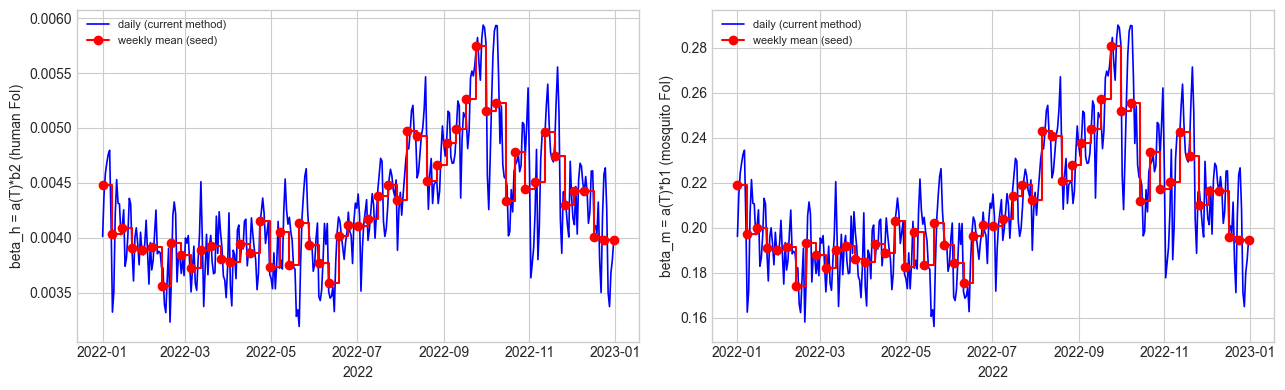

Climate beta_h weekly range: [0.00356, 0.00575]
Climate beta_m weekly range: [0.17407, 0.28071]


In [8]:
nw = n_weeks_in_year(YEAR)
bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
dates_year = observed_for_year(YEAR)['date']
week_starts = dates_year[::7][:nw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ylab, d, w in [
    (axes[0], 'beta_h = a(T)*b2 (human FoI)', bh_daily, bh_week),
    (axes[1], 'beta_m = a(T)*b1 (mosquito FoI)', bm_daily, bm_week),
]:
    ax.plot(dates_year, d, 'b-', lw=1.2, label='daily (current method)')
    ax.step(week_starts, w, 'r-o', where='post', label='weekly mean (seed)')
    ax.set_ylabel(ylab)
    ax.set_xlabel(str(YEAR))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Climate beta_h weekly range: [{bh_week.min():.5f}, {bh_week.max():.5f}]')
print(f'Climate beta_m weekly range: [{bm_week.min():.5f}, {bm_week.max():.5f}]')

## Step 4 - lmfit least-squares fit of the free weekly betas

- **106 free parameters** (`beta_h` and `beta_m` for each of the 53 weekly buckets).
- Seeded from the weekly-mean climate beta above.
- Objective = weighted residuals against the 365 daily observed cases
  (same exponential early-emphasis weighting as the yearly calibration).
- `max_nfev` caps the solver budget (default 1200; `success=False` only means the
  budget was hit before full convergence).

This cell is the long step (~5-15 min).

In [10]:
QUICK = False
MAX_NFEV = 300 if QUICK else 1200
WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)

print(f'Fitting 2x{n_weeks_in_year(YEAR)} free weekly betas for {YEAR} with lmfit least_squares (max_nfev={MAX_NFEV})...')

payload = run_weekly_beta_fit(
    year=YEAR,  
    weight_kw=WEIGHT_KW,
    max_nfev=MAX_NFEV,
    verbose=True,
)

# Load results for display
res = load_weekly_results(YEAR)  # Updated function
if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")

Fitting 2x53 free weekly betas for 2022 with lmfit least_squares (max_nfev=1200)...
Year 2022: Baseline wMSE (climate-driven beta): 56,336.5
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 56,346.7 (nfev=115, success=True)
Saved results to weekly_beta_results_2022.json
Year: 2022  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 56,336.5
Weekly-fit wMSE (free beta(t)): 56,346.7


## Step 5 - Results summary

`baseline_wmse` is the weighted MSE with the climate-driven beta (refined 2017
params) - it reproduces `lmfit_results.json`. `weekly_fit_wmse` is the value after
freeing the weekly betas. The gap shows how much of the misfit is due to the
climate formulation of beta.

In [12]:
res = load_weekly_results(YEAR)  

if res:
    print(f"Year: {res['year']}  (n_weeks={res['n_weeks']})")
    print(f"Baseline wMSE  (climate-driven beta): {res['baseline_wmse']:,.1f}")
    print(f"Weekly-fit wMSE (free beta(t)): {res['weekly_fit_wmse']:,.1f}")
    if res['baseline_wmse'] > 0:
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"wMSE reduction: {reduction:,.1f}%")
    print(f"lmfit: nfev={res['nfev']}, success={res['success']}, chisqr={res['chisqr']:.4g}")

Year: 2022  (n_weeks=53)
Baseline wMSE  (climate-driven beta): 56,336.5
Weekly-fit wMSE (free beta(t)): 56,346.7
wMSE reduction: -0.0%
lmfit: nfev=115, success=True, chisqr=7.925e+07


## Step 6 - Fitted weekly beta vs climate-driven beta

Where the fitted free `beta(t)` departs from `a(T)·b1` / `a(T)·b2` indicates
where the climate formulation is missing or misspecified (e.g. a lag between
rainfall and breeding, or a non-temperature mechanism).

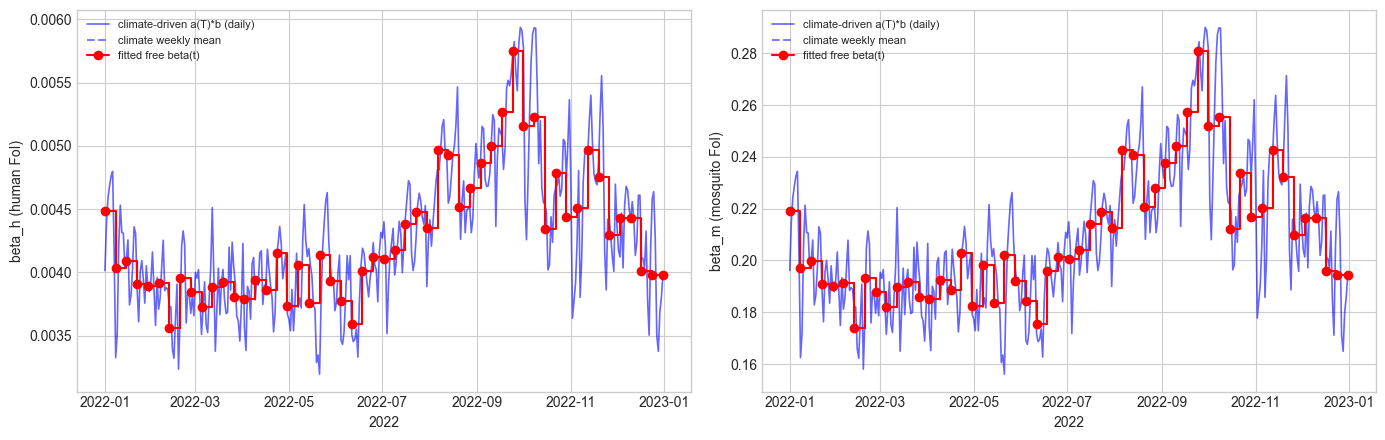

 week       date  beta_h_climate  beta_h_fitted  beta_m_climate  beta_m_fitted
    0 2022-01-01          0.0045         0.0045          0.2192         0.2192
    1 2022-01-08          0.0040         0.0040          0.1971         0.1971
    2 2022-01-15          0.0041         0.0041          0.1997         0.1997
    3 2022-01-22          0.0039         0.0039          0.1907         0.1907
    4 2022-01-29          0.0039         0.0039          0.1900         0.1900
    5 2022-02-05          0.0039         0.0039          0.1912         0.1912
    6 2022-02-12          0.0036         0.0036          0.1741         0.1741
    7 2022-02-19          0.0040         0.0040          0.1931         0.1931
    8 2022-02-26          0.0038         0.0038          0.1877         0.1877
    9 2022-03-05          0.0037         0.0037          0.1822         0.1822
   10 2022-03-12          0.0039         0.0039          0.1899         0.1899
   11 2022-03-19          0.0039         0.0039     

In [14]:
res = load_weekly_results(YEAR)
if res:
    # Get the fitted betas
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    bh_cli = np.array(res['beta_h_weekly_climate'])
    bm_cli = np.array(res['beta_m_weekly_climate'])
    nw = len(bh_fit)
    dates_year = observed_for_year(YEAR)['date']
    week_starts = dates_year[::7][:nw]
    
    bh_daily, bm_daily = climate_beta_daily(
        YEAR, res['climate_params']['b1'], res['climate_params']['b2']
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, name, fit, cli_week, cli_daily in [
        (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli, bh_daily),
        (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli, bm_daily),
    ]:
        ax.plot(dates_year, cli_daily, 'b-', lw=1.2, alpha=0.6, 
                label='climate-driven a(T)*b (daily)')
        ax.step(week_starts, cli_week, 'b--', where='post', alpha=0.5, 
                label='climate weekly mean')
        ax.step(week_starts, fit, 'r-o', where='post', label='fitted free beta(t)')
        ax.set_ylabel(name)
        ax.set_xlabel(str(YEAR))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    # Table
    tbl = pd.DataFrame({
        'week': np.arange(nw),
        'date': week_starts.values,
        'beta_h_climate': bh_cli,
        'beta_h_fitted': bh_fit,
        'beta_m_climate': bm_cli,
        'beta_m_fitted': bm_fit,
    })
    print(tbl.round(4).to_string(index=False))

## Step 7 - Model vs observed cases with the free weekly beta

Overlaying the model trajectory (with free weekly beta) on the observed cases.

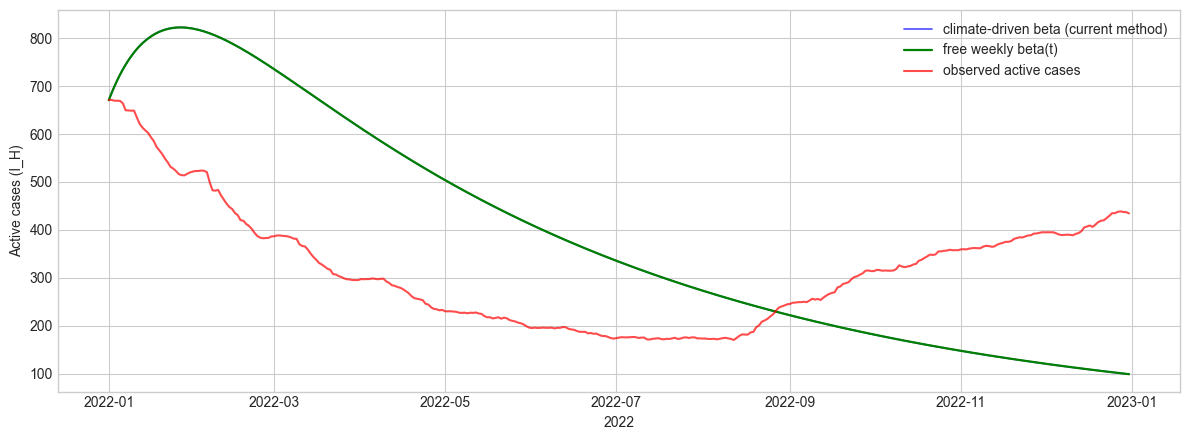

In [16]:
res = load_weekly_results(YEAR)
if res:
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    bh_fit = np.array(res['beta_h_weekly_fitted'])
    bm_fit = np.array(res['beta_m_weekly_fitted'])
    
    dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
    obs = observed_for_year(YEAR)
    
    full = dict(fixed)
    full['b1'], full['b2'] = b1, b2
    dates0, IH0, _ = simulate_year(YEAR, state0, full)
    
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(pd.to_datetime(dates0), IH0, 'b-', lw=1.2, alpha=0.7, 
            label='climate-driven beta (current method)')
    ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, 
            label='free weekly beta(t)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, 
            label='observed active cases')
    ax.set_ylabel('Active cases (I_H)')
    ax.set_xlabel(str(YEAR))
    ax.legend()
    plt.tight_layout()
    plt.show()

## Notes

- `success=False` just means the least_squares evaluation budget was reached; the
  reported betas are the best found within that budget.
- The free weekly beta can absorb any mechanism the fixed climate formulation
  misses (lagged rain effects, behaviour, reporting artefacts), so a large wMSE
  improvement only localises *where* the formulation fails - it is not a
  predictive model.
- Results are saved to `weekly_beta_results.json`.
- To change the weighting or the fit budget, edit `WEIGHT_KW` / `MAX_NFEV` in
  Step 4 and re-run from there.

## Step 8 - Analyze multiple years

In [19]:
YEARS_TO_ANALYZE = [2017, 2018, 2019, 2020, 2021, 2022, 2023]  # Add more years as needed

results_summary = []
for year in YEARS_TO_ANALYZE:
    try:
        res = load_weekly_results(year)
        if res:
            results_summary.append({
                'year': year,
                'baseline_wmse': res['baseline_wmse'],
                'weekly_fit_wmse': res['weekly_fit_wmse'],
                'reduction': (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100,
                'nfev': res['nfev'],
                'success': res['success']
            })
    except Exception as e:
        print(f"Could not load results for {year}: {e}")

if results_summary:
    df_summary = pd.DataFrame(results_summary)
    print("\n=== Summary Across Years ===")
    print(df_summary.round(1).to_string(index=False))


=== Summary Across Years ===
 year  baseline_wmse  weekly_fit_wmse  reduction  nfev  success
 2022        56336.5          56346.7       -0.0   115     True


In [20]:
# Add this cell after the imports and configuration

# ---------------------------------------------------------------------------
# Multi-Year Analysis
# ---------------------------------------------------------------------------
QUICK = False  # Set to True for quick test runs

# Store results for each year
all_results = {}
all_trajectories = {}

for year in YEARS_TO_ANALYZE:
    print(f"\n{'='*60}")
    print(f"Analyzing year: {year}")
    print(f"{'='*60}")
    
    # Set the year
    YEAR = year
    
    # Step 2: Load parameters
    fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
    print(f'Fixed params for {YEAR} (from lmfit_results.json):')
    for k, v in fixed.items():
        print(f'  {k:<8}= {v:.6g}')
    print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
    print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')
    
    # Step 3: Climate beta visualization (optional - comment out if you want to skip plots)
    nw = n_weeks_in_year(YEAR)
    bh_daily, bm_daily = climate_beta_daily(YEAR, b1, b2)
    bh_week, bm_week = climate_beta_weekly(YEAR, b1, b2, nw)
    
    # Step 4: Run the fit
    MAX_NFEV = 300 if QUICK else 1200
    WEIGHT_KW = dict(DEFAULT_WEIGHT_KW)
    
    print(f'Fitting {2 * n_weeks_in_year(YEAR)} free weekly betas for {YEAR}...')
    
    payload = run_weekly_beta_fit(
        year=YEAR,
        weight_kw=WEIGHT_KW,
        max_nfev=MAX_NFEV,
        verbose=True,
    )
    
    # Load and store results
    res = load_weekly_results(YEAR)
    if res:
        all_results[year] = res
        print(f"\nYear {year} Results:")
        print(f"  Baseline wMSE: {res['baseline_wmse']:,.1f}")
        print(f"  Weekly-fit wMSE: {res['weekly_fit_wmse']:,.1f}")
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        print(f"  Reduction: {reduction:.1f}%")
        print(f"  nfev: {res['nfev']}, success: {res['success']}")
        
        # Step 5: Get trajectory
        fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
        bh_fit = np.array(res['beta_h_weekly_fitted'])
        bm_fit = np.array(res['beta_m_weekly_fitted'])
        dates, IH, _ = simulate_year(YEAR, state0, fixed, bh_fit, bm_fit)
        all_trajectories[year] = (dates, IH)

print(f"\n{'='*60}")
print("Analysis complete for all years!")
print(f"{'='*60}")


Analyzing year: 2017
Fixed params for 2017 (from lmfit_results.json):
  H0      = 27.688
  k       = 0.311988
  phi     = 0.172876
  tau_H   = 19.9508
  gamma   = 0.00676763
  omega   = 0.0775941
  M_prime = 53826
Climate-driven scalars: b1=0.334982, b2=0.0243832
Year days: 365, weekly buckets: 53
Fitting 106 free weekly betas for 2017...
Year 2017: Baseline wMSE (climate-driven beta): 118,543.6
Fitting 106 free weekly betas (beta_h, beta_m)...
Fit done: wMSE = 942.2 (nfev=1083, success=True)
Saved results to weekly_beta_results_2017.json

Year 2017 Results:
  Baseline wMSE: 118,543.6
  Weekly-fit wMSE: 942.2
  Reduction: 99.2%
  nfev: 1083, success: True

Analyzing year: 2018
Fixed params for 2018 (from lmfit_results.json):
  H0      = 21.3395
  k       = 0.0477993
  phi     = 0.499556
  tau_H   = 19.8894
  gamma   = 0.00684136
  omega   = 0.0700436
  M_prime = 51198.3
Climate-driven scalars: b1=0.499963, b2=0.0175703
Year days: 365, weekly buckets: 53
Fitting 106 free weekly betas f


KeyboardInterrupt



In [ ]:
## ---------------------------------------------------------------------------
# Compare Results Across Years
# ---------------------------------------------------------------------------

if len(all_results) > 0:
    n_years = len(all_results)
    fig, axes = plt.subplots(1, n_years, figsize=(6*n_years, 4))
    if n_years == 1:
        axes = [axes]
    
    for idx, (year, res) in enumerate(all_results.items()):
        ax = axes[idx]
        
        # Get data
        fixed, state0, fracs, b1, b2 = load_refined_params(year)
        bh_fit = np.array(res['beta_h_weekly_fitted'])
        bm_fit = np.array(res['beta_m_weekly_fitted'])
        
        dates, IH, _ = simulate_year(year, state0, fixed, bh_fit, bm_fit)
        obs = observed_for_year(year)
        
        # Plot
        ax.plot(pd.to_datetime(dates), IH, 'g-', lw=1.6, label='free weekly beta(t)')
        ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, label='observed')
        
        reduction = (1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100
        ax.set_title(f'{year}\nwMSE: {res["weekly_fit_wmse"]:.0f} ({reduction:.1f}% reduction)')
        ax.set_xlabel('Date')
        ax.set_ylabel('Active cases')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Compare Fitted Beta Curves Across Years
# ---------------------------------------------------------------------------

if len(all_results) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    for year, res in all_results.items():
        bh_fit = np.array(res['beta_h_weekly_fitted'])
        bm_fit = np.array(res['beta_m_weekly_fitted'])
        bh_cli = np.array(res['beta_h_weekly_climate'])
        bm_cli = np.array(res['beta_m_weekly_climate'])
        
        nw = len(bh_fit)
        dates_year = observed_for_year(year)['date']
        week_starts = dates_year[::7][:nw]
        
        # Beta_h
        axes[0].plot(week_starts, bh_fit, 'o-', label=f'{year} fitted', alpha=0.7)
        axes[0].plot(week_starts, bh_cli, '--', label=f'{year} climate', alpha=0.5)
        
        # Beta_m
        axes[1].plot(week_starts, bm_fit, 'o-', label=f'{year} fitted', alpha=0.7)
        axes[1].plot(week_starts, bm_cli, '--', label=f'{year} climate', alpha=0.5)
    
    axes[0].set_ylabel('beta_h (human FoI)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_ylabel('beta_m (mosquito FoI)')
    axes[1].set_xlabel('Date')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Detailed Summary Table
# ---------------------------------------------------------------------------

if len(all_results) > 0:
    summary_data = []
    for year, res in all_results.items():
        summary_data.append({
            'Year': year,
            'Baseline wMSE': f"{res['baseline_wmse']:,.0f}",
            'Weekly-fit wMSE': f"{res['weekly_fit_wmse']:,.0f}",
            'Reduction %': f"{(1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100:.1f}%",
            'nfev': res['nfev'],
            'Success': res['success'],
            'n_weeks': res['n_weeks']
        })
    
    df_summary = pd.DataFrame(summary_data)
    print("\n=== Detailed Summary Across Years ===\n")
    print(df_summary.to_string(index=False))
    
    # Also show parameter values for each year
    print("\n=== Fitted Parameters Across Years ===\n")
    param_data = []
    for year in all_results.keys():
        fixed, state0, fracs, b1, b2 = load_refined_params(year)
        param_data.append({
            'Year': year,
            'b1': f"{b1:.4f}",
            'b2': f"{b2:.4f}",
            'H0': f"{fixed['H0']:.2f}",
            'k': f"{fixed['k']:.3f}",
            'phi': f"{fixed['phi']:.3f}",
            'tau_H': f"{fixed['tau_H']:.2f}",
            'gamma': f"{fixed['gamma']:.4f}",
            'omega': f"{fixed['omega']:.4f}",
            'M_prime': f"{fixed['M_prime']:,.0f}"
        })
    df_params = pd.DataFrame(param_data)
    print(df_params.to_string(index=False))

In [ ]:
# ---------------------------------------------------------------------------
# Interactive Year Viewer
# ---------------------------------------------------------------------------

# First, make sure we have results for all years
YEARS_TO_ANALYZE = [2017, 2018, 2019, 2020, 2021, 2022, 2023]  # Add years as needed

# Load existing results (or run fits if needed)
available_results = {}
for year in YEARS_TO_ANALYZE:
    res = load_weekly_results(year)
    if res:
        available_results[year] = res
        print(f"✓ Loaded results for {year}")
    else:
        print(f"✗ No results found for {year}")

if available_results:
    # Select a year to view in detail
    print(f"\nAvailable years: {list(available_results.keys())}")
    selected_year = int(input("Enter year to view in detail: "))
    
    if selected_year in available_results:
        # Display detailed results for selected year
        YEAR = selected_year
        res = available_results[YEAR]
        
        print(f"\n{'='*60}")
        print(f"Detailed Results for {YEAR}")
        print(f"{'='*60}")
        print(f"Baseline wMSE: {res['baseline_wmse']:,.1f}")
        print(f"Weekly-fit wMSE: {res['weekly_fit_wmse']:,.1f}")
        print(f"Reduction: {(1 - res['weekly_fit_wmse'] / res['baseline_wmse']) * 100:.1f}%")
        print(f"nfev: {res['nfev']}, success: {res['success']}")
        print(f"n_weeks: {res['n_weeks']}")
        
        # Show beta curves
        bh_fit = np.array(res['beta_h_weekly_fitted'])
        bm_fit = np.array(res['beta_m_weekly_fitted'])
        bh_cli = np.array(res['beta_h_weekly_climate'])
        bm_cli = np.array(res['beta_m_weekly_climate'])
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        for ax, name, fit, cli in [
            (axes[0], 'beta_h (human FoI)', bh_fit, bh_cli),
            (axes[1], 'beta_m (mosquito FoI)', bm_fit, bm_cli),
        ]:
            dates_year = observed_for_year(YEAR)['date']
            week_starts = dates_year[::7][:len(fit)]
            ax.plot(week_starts, cli, 'b--', label='climate-driven')
            ax.plot(week_starts, fit, 'r-o', label='fitted')
            ax.set_title(f'{YEAR} - {name}')
            ax.set_xlabel('Date')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Year {selected_year} not available")

In [ ]:
YEAR = 2023  # Change this to any year with available data (e.g., 2018, 2019, etc.)

# Validate year has data
try:
    obs = observed_for_year(YEAR)
    if len(obs) == 0:
        raise ValueError(f"No case data for year {YEAR}")
    start = f"{YEAR}-01-01"
    end = f"{YEAR}-12-31"
    clim = climate_data[
        (climate_data["date"] >= start) & (climate_data["date"] <= end)
    ]
    if len(clim) == 0:
        raise ValueError(f"No climate data for year {YEAR}")
    print(f"✓ Year {YEAR} has available data")
except Exception as e:
    print(f"✗ Error: {e}")
    print(f"Available years: {sorted(rural_cases_df['date'].dt.year.unique())}")

print('\n')

fixed, state0, fracs, b1, b2 = load_refined_params(YEAR)
print(f'Fixed params for {YEAR} (from lmfit_results.json):')
for k, v in fixed.items():
    print(f'  {k:<8}= {v:.6g}')
print(f'Climate-driven scalars: b1={b1:.6g}, b2={b2:.6g}')
print('IC fractions:', {k: f'{v:.6g}' for k, v in fracs.items()})
print('Initial state:', state0)
print(f'Year days: {days_in_year(YEAR)}, weekly buckets: {n_weeks_in_year(YEAR)}')